In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

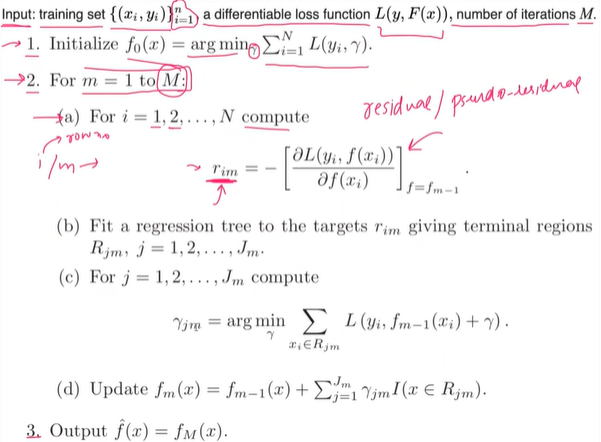

In [2]:
data = {
    'R&D Spend': [165.0, 101.0, 29.0],
    'Administration': [137.0, 92.0, 127.0],
    'Marketing Spend': [472.0, 250.0, 201.0],
    'Profit': [192.0, 144.0, 91.0]
}

df = pd.DataFrame(data)

df.head()

,R&D Spend,Administration,Marketing Spend,Profit
0,165.0,137.0,472.0,192.0
1,101.0,92.0,250.0,144.0
2,29.0,127.0,201.0,91.0


In [3]:
df['f0(X)'] = df['Profit'].mean()

In [4]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X)
0,165.0,137.0,472.0,192.0,142.333333
1,101.0,92.0,250.0,144.0,142.333333
2,29.0,127.0,201.0,91.0,142.333333


In [5]:
df['ri1'] = df['Profit'] - df['f0(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333


In [6]:
from sklearn.tree import DecisionTreeRegressor

dt1 = DecisionTreeRegressor(max_depth=1)
X = df.iloc[:,0:3]
y = df.iloc[:,5]

dt1.fit(X,y)

DecisionTreeRegressor(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 65.0\nsquared_error = 1701.556\nsamples = 3\nvalue = -0.0'),
 Text(0.25, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = -51.333'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 576.0\nsamples = 2\nvalue = 25.667'),
 Text(0.625, 0.5, '  False')]

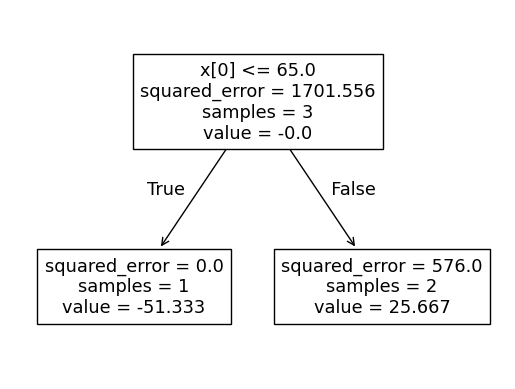

In [7]:
from  sklearn.tree import plot_tree

plot_tree(dt1)

In [8]:
df['h1(X)'] = dt1.predict(X)

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333


In [9]:
learning_rate = 0.1
df['f1(X)'] = df['f0(X)'] + learning_rate*df['h1(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2


In [10]:
df['ri2'] = df['Profit'] - df['f1(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2


**First Iteration Complete Now time for the second iteration**

**Now this time our**

**Input :** **R&D Spend	Administration	Marketing Spend**

**Output : ri2**



In [11]:
X = df[['R&D Spend','Administration','Marketing Spend']]
y = df['ri2']
tree2 = DecisionTreeRegressor(max_depth=1)
tree2.fit(X,y)
df['h2(X)'] = tree2.predict(X)

In [12]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55


In [13]:
df['f2(X)'] = df['f1(X)'] + learning_rate*df['h2(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),f2(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,149.610
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,142.545
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,134.845


In [14]:
df['ri3'] = df['Profit'] - df['f2(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),f2(X),ri3
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,149.610,42.390
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,142.545,1.455
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,134.845,-43.845


**Next Iteration ->**

In [15]:
X = df[['R&D Spend','Administration','Marketing Spend']]
y = df['ri3']
tree2 = DecisionTreeRegressor(max_depth=1)
tree2.fit(X,y)
df['h3(X)'] = tree2.predict(X)
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),f2(X),ri3,h3(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,149.610,42.390,21.9225
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,142.545,1.455,21.9225
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,134.845,-43.845,-43.8450


In [16]:
df['f3(X)'] = df['f2(X)'] + learning_rate*df['h3(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),f2(X),ri3,h3(X),f3(X)
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,149.610,42.390,21.9225,151.80225
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,142.545,1.455,21.9225,144.73725
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,134.845,-43.845,-43.8450,130.46050


In [17]:
df['ri4'] = df['Profit'] - df['f3(X)']
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),f2(X),ri3,h3(X),f3(X),ri4
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,149.610,42.390,21.9225,151.80225,40.19775
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,142.545,1.455,21.9225,144.73725,-0.73725
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,134.845,-43.845,-43.8450,130.46050,-39.46050


In [18]:
def Iteration():
  X = df[['R&D Spend','Administration','Marketing Spend']]
  for i in range(4,7):
    y = df[f'ri{i}']
    dt = DecisionTreeRegressor(max_depth=1)
    dt.fit(X,y)
    df[f'h{i}(X)'] = dt.predict(X)
    df[f'f{i}(X)'] = df[f'f{i-1}(X)'] + learning_rate*df[f'h{i}(X)']
    df[f'ri{i+1}'] = df['Profit'] - df[f'f{i}(X)']



In [19]:
Iteration()

In [20]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),...,ri4,h4(X),f4(X),ri5,h5(X),f5(X),ri6,h6(X),f6(X),ri7
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,...,40.19775,40.197750,155.822025,36.177975,18.725306,157.694556,34.305444,34.305444,161.125100,30.874900
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,...,-0.73725,-20.098875,142.727363,1.272637,18.725306,144.599893,-0.599893,-17.152722,142.884621,1.115379
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,...,-39.46050,-20.098875,128.450613,-37.450613,-37.450613,124.705551,-33.705551,-17.152722,122.990279,-31.990279


In [21]:
def Iteration(initial,end):
  X = df[['R&D Spend','Administration','Marketing Spend']]
  for i in range(initial,end):
    y = df[f'ri{i}']
    dt = DecisionTreeRegressor(max_depth=1)
    dt.fit(X,y)
    df[f'h{i}(X)'] = dt.predict(X)
    df[f'f{i}(X)'] = df[f'f{i-1}(X)'] + learning_rate*df[f'h{i}(X)']
    df[f'ri{i+1}'] = df['Profit'] - df[f'f{i}(X)']

In [22]:
Iteration(7,20)

In [23]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),...,ri17,h17(X),f17(X),ri18,h18(X),f18(X),ri19,h19(X),f19(X),ri20
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,...,13.964748,7.280722,178.763324,13.236676,13.236676,180.086992,11.913008,6.221733,180.709165,11.290835
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,...,0.596696,7.280722,144.131376,-0.131376,-6.618338,143.469542,0.530458,6.221733,144.091715,-0.091715
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,...,-14.561444,-14.561444,104.105300,-13.105300,-6.618338,103.443466,-12.443466,-12.443466,102.199119,-11.199119


In [24]:
Iteration(20,31)
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),...,ri28,h28(X),f28(X),ri29,h29(X),f29(X),ri30,h30(X),f30(X),ri31
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,...,5.970361,2.989299,186.328569,5.671431,5.671431,186.895712,5.104288,5.104288,187.406141,4.593859
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,...,0.008238,2.989299,144.290692,-0.290692,-2.835716,144.007120,-0.007120,-2.552144,143.751906,0.248094
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,...,-5.978599,-5.978599,96.380739,-5.380739,-2.835716,96.097168,-5.097168,-2.552144,95.841953,-4.841953


In [25]:
Iteration(31,40)
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),...,ri37,h37(X),f37(X),ri38,h38(X),f38(X),ri39,h39(X),f39(X),ri40
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,...,3.013158,3.013158,189.288158,2.711842,2.711842,189.559342,2.440658,1.286227,189.687965,2.312035
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,...,-0.154454,-1.506579,144.003796,-0.003796,-1.355921,143.868204,0.131796,1.286227,143.996826,0.003174
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,...,-2.858704,-1.506579,93.708046,-2.708046,-1.355921,93.572454,-2.572454,-2.572454,93.315209,-2.315209


In [26]:
Iteration(40,50)
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(X),ri1,h1(X),f1(X),ri2,h2(X),...,ri47,h47(X),f47(X),ri48,h48(X),f48(X),ri49,h49(X),f49(X),ri50
0,165.0,137.0,472.0,192.0,142.333333,49.666667,25.666667,144.9,47.1,47.10,...,1.296691,0.683351,190.771644,1.228356,0.615016,190.833146,1.166854,1.166854,190.949831,1.050169
1,101.0,92.0,250.0,144.0,142.333333,1.666667,25.666667,144.9,-0.9,-23.55,...,0.070011,0.683351,143.998324,0.001676,0.615016,144.059825,-0.059825,-0.583427,144.001483,-0.001483
2,29.0,127.0,201.0,91.0,142.333333,-51.333333,-51.333333,137.2,-46.2,-23.55,...,-1.366703,-1.366703,92.230032,-1.230032,-1.230032,92.107029,-1.107029,-0.583427,92.048686,-1.048686


In [27]:
from sklearn.ensemble import GradientBoostingRegressor
X = df[['R&D Spend', 'Administration', 'Marketing Spend']]
y = df['Profit']
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=1,
    random_state=42
)
gbr.fit(X,y)

GradientBoostingRegressor(max_depth=1, n_estimators=50, random_state=42)

In [28]:
y_pred = gbr.predict(X)
print(y_pred)

[191.05484786 143.9489742   91.99617794]


In [29]:
result = pd.DataFrame({
    'Actual Profit':y,
    'Predicted Profit':y_pred
})
result

,Actual Profit,Predicted Profit
0,192.0,191.054848
1,144.0,143.948974
2,91.0,91.996178


In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y, y_pred))
print("MSE :", mean_squared_error(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred) ** 0.5)
print("R²  :", r2_score(y, y_pred))

MAE : 0.6641186294379082
MSE : 0.629428899987866
RMSE: 0.7933655525593899
R²  : 0.9996300861891151


These were the calculations or results on the training data and our dataset is too small right

after this we have to do train_test_split and fit and evaluate and then predict it on the unseen dataset

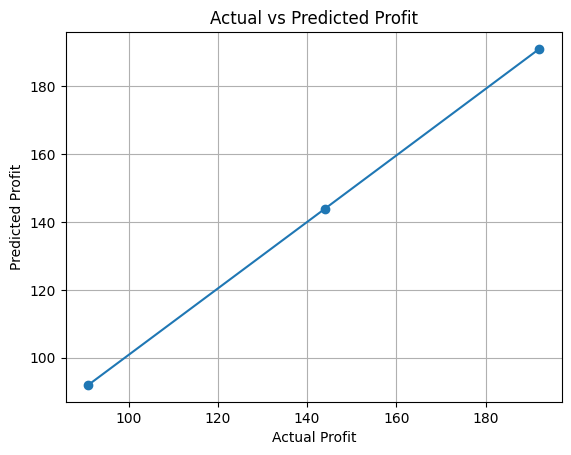

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y, y_pred)
plt.plot(y,y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.grid(True)

plt.show()

In [32]:
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

X = df[['R&D Spend', 'Administration', 'Marketing Spend']]
y = df['Profit']

n_estimators = [1, 2, 3, 5, 10, 20, 30, 40, 50]

errors = []

for n in n_estimators:

    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=1,
        random_state=42
    )

    model.fit(X, y)

    pred = model.predict(X)

    # Mean Absolute Error
    mae = mean_absolute_error(y, pred)

    errors.append(mae)

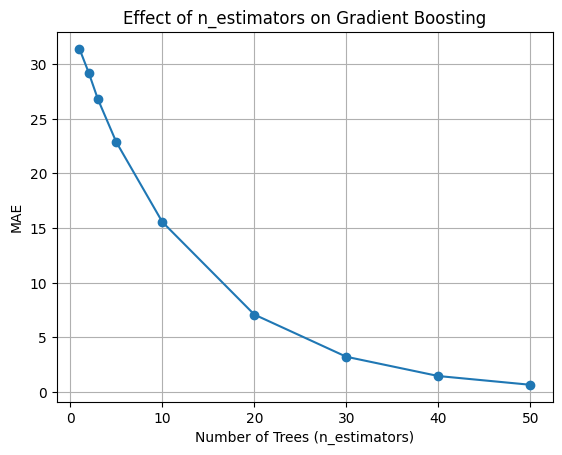

In [33]:
plt.plot(n_estimators, errors, marker='o')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("MAE")
plt.title("Effect of n_estimators on Gradient Boosting")
plt.grid(True)
plt.show()

**This notebook uses a small dataset to demonstrate the internal working of Gradient Boosting Regression step-by-step. The goal is conceptual understanding rather than model benchmarking or real-world prediction performance.**

In [34]:
import joblib

joblib.dump(gbr, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

In [35]:
X_new = [
    [120, 100, 300],
    [150, 80, 400],
    [50, 110, 180]
]
loaded_model = joblib.load("gradient_boosting_model.pkl")
predictions = loaded_model.predict(X_new)
for i, prediction in enumerate(predictions):
    print(f"Sample {i+1}: Predicted Profit = {prediction:.2f}")

Sample 1: Predicted Profit = 143.95
Sample 2: Predicted Profit = 183.31
Sample 3: Predicted Profit = 92.00
